# 04 — MediaPipe Hands sanity (gesture-classifier prep)

**Goal.** Before training a gesture classifier we need to know **at what camera-to-hand distances MediaPipe Hands actually returns a usable skeleton**. That puts a hard floor on what the downstream classifier can possibly see.

**Data.** Four clips captured on the same phone, same room, with one person making a few gestures at fixed distances from the camera:

| clip            | recorded distance |
|---------------- | ----------------- |
| `1meters.MOV`   | ~ 1 m             |
| `2meters.MOV`   | ~ 2 m             |
| `3meters.MOV`   | ~ 3 m             |
| `4meters.MOV`   | ~ 4 m             |

**What this notebook does.**

1. Run MediaPipe Hands on each clip (`gesture/mediapipe_overlay.py`) → overlay video + landmark CSV. Outputs are cached under `data/gesture/{1m,2m,3m,4m}_*`.
2. Detection-rate vs distance — primary metric for "where does the pipeline break".
3. Hand-span vs distance — how big is the hand in the frame at each range (drives downstream classifier resolution).
4. Per-clip wrist trajectories (gestures should be visible as motion bursts).
5. Sample overlay frame from each clip for visual sanity.

> The actual MediaPipe run uses MediaPipe `Hands` (2-D landmark model, 21 keypoints per hand). For a gesture classifier we will plug those 21×3 keypoints into a small temporal model in a later notebook.


In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT))

from gesture.mediapipe_overlay import run as run_mediapipe

RAW_DIR    = Path('~/Desktop/uav_perception/media_hands').expanduser()
OUT_DIR    = REPO_ROOT / 'data' / 'gesture'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLIPS = [
    {'dist_m': 1, 'video': RAW_DIR / '1meters.MOV', 'prefix': OUT_DIR / '1m'},
    {'dist_m': 2, 'video': RAW_DIR / '2meters.MOV', 'prefix': OUT_DIR / '2m'},
    {'dist_m': 3, 'video': RAW_DIR / '3meters.MOV', 'prefix': OUT_DIR / '3m'},
    {'dist_m': 4, 'video': RAW_DIR / '4meters.MOV', 'prefix': OUT_DIR / '4m'},
]

print('Raw video dir:', RAW_DIR, '— exists:', RAW_DIR.exists())
print('Output dir:   ', OUT_DIR)
for c in CLIPS:
    print(f"  {c['dist_m']} m  video exists: {str(c['video'].exists()):5}  prefix: {c['prefix']}")


Raw video dir: /Users/simayyalcin/Desktop/uav_perception/media_hands — exists: True
Output dir:    /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/gesture
  1 m  video exists: True   prefix: /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/gesture/1m
  2 m  video exists: True   prefix: /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/gesture/2m
  3 m  video exists: True   prefix: /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/gesture/3m
  4 m  video exists: True   prefix: /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/gesture/4m


## 1. Run MediaPipe Hands on each clip

The cell below skips the detection step if the cached CSV is already on disk; rerun by deleting `data/gesture/{1m,2m,3m,4m}_keypoints.csv`. Each clip takes ~30 s on a CPU at 30 fps.

In [2]:
for c in CLIPS:
    kp_csv = c['prefix'].with_name(c['prefix'].name + '_keypoints.csv')
    if kp_csv.exists():
        print(f"{c['dist_m']} m — cached ({kp_csv.name}), skipping detection.")
        continue
    print(f"\n--- detecting {c['dist_m']} m ---")
    run_mediapipe(
        video_path=c['video'],
        output_prefix=c['prefix'],
        max_hands=2,
        detection_confidence=0.5,
        tracking_confidence=0.5,
    )


1 m — cached (1m_keypoints.csv), skipping detection.
2 m — cached (2m_keypoints.csv), skipping detection.
3 m — cached (3m_keypoints.csv), skipping detection.
4 m — cached (4m_keypoints.csv), skipping detection.


## 2. Detection rate and hand-size vs distance

For each clip we compute:

* `detection_rate` — fraction of frames in which MediaPipe returned at least one hand.
* `mean_score`    — average per-hand detection score (MediaPipe internal confidence).
* `median_handspan` — median normalised hand bounding-box size; proxy for **how many pixels** the hand actually occupies. `0.20` means the hand spans ~20 % of the frame width.

Hand span is the strongest predictor of classifier viability — once the hand is < ~5 % of the frame the 21 keypoints get spatially-aliased and per-finger geometry becomes unreliable.

In [3]:
import cv2

def clip_stats(prefix: Path, video: Path) -> dict:
    kp = pd.read_csv(prefix.with_name(prefix.name + '_keypoints.csv'))
    cap = cv2.VideoCapture(str(video))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.release()

    xs = kp[[f'kp{i}_x' for i in range(21)]].values
    ys = kp[[f'kp{i}_y' for i in range(21)]].values
    span = np.maximum(xs.max(1) - xs.min(1), ys.max(1) - ys.min(1))

    return {
        'frames':            n_frames,
        'fps':               fps,
        'det_frames':        kp['frame'].nunique(),
        'detection_rate_%':  100.0 * kp['frame'].nunique() / n_frames,
        'hand_instances':    len(kp),
        'mean_score':        float(kp['score'].mean()),
        'median_handspan_%': 100.0 * float(np.median(span)),
    }

rows = []
for c in CLIPS:
    s = clip_stats(c['prefix'], c['video'])
    s.update({'dist_m': c['dist_m']})
    rows.append(s)

summary = pd.DataFrame(rows)[
    ['dist_m', 'frames', 'fps', 'det_frames', 'detection_rate_%',
     'hand_instances', 'mean_score', 'median_handspan_%']
]

display(summary.style.format({
    'fps':               '{:.1f}',
    'detection_rate_%':  '{:.1f}',
    'mean_score':        '{:.3f}',
    'median_handspan_%': '{:.1f}',
}))


,dist_m,frames,fps,det_frames,detection_rate_%,hand_instances,mean_score,median_handspan_%
0,1,498,30.0,380,76.3,643,0.962,34.5
1,2,761,30.0,601,79.0,936,0.959,13.2
2,3,797,30.0,448,56.2,610,0.931,8.4
3,4,664,30.0,206,31.0,206,0.912,5.4


### Plots: how the pipeline scales with distance

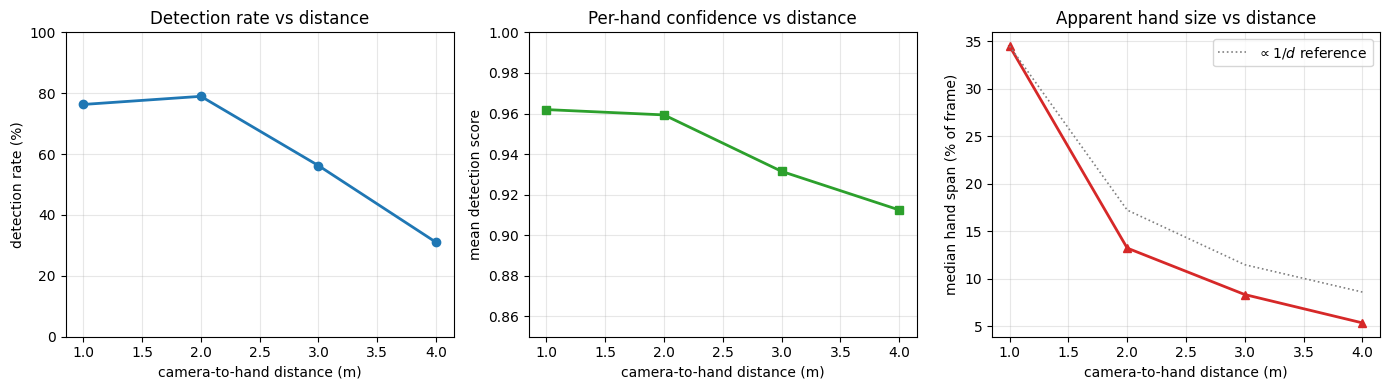

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(summary['dist_m'], summary['detection_rate_%'], 'o-', color='#1f77b4', lw=2)
axes[0].set_xlabel('camera-to-hand distance (m)')
axes[0].set_ylabel('detection rate (%)')
axes[0].set_title('Detection rate vs distance')
axes[0].set_ylim(0, 100)
axes[0].grid(alpha=0.3)

axes[1].plot(summary['dist_m'], summary['mean_score'], 's-', color='#2ca02c', lw=2)
axes[1].set_xlabel('camera-to-hand distance (m)')
axes[1].set_ylabel('mean detection score')
axes[1].set_title('Per-hand confidence vs distance')
axes[1].set_ylim(0.85, 1.0)
axes[1].grid(alpha=0.3)

axes[2].plot(summary['dist_m'], summary['median_handspan_%'], '^-', color='#d62828', lw=2)
# 1/d reference (rescaled to pass through the 1 m point)
ref = summary['median_handspan_%'].iloc[0] / summary['dist_m']
axes[2].plot(summary['dist_m'], ref, ':', color='gray', lw=1.2,
             label=r'$\propto 1/d$ reference')
axes[2].set_xlabel('camera-to-hand distance (m)')
axes[2].set_ylabel('median hand span (% of frame)')
axes[2].set_title('Apparent hand size vs distance')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Wrist trajectories per clip

Plotting `kp0` (the wrist landmark) over time gives a quick view of "is the gesture activity actually being captured?". Gestures should show up as a few seconds of motion separated by stationary intervals.

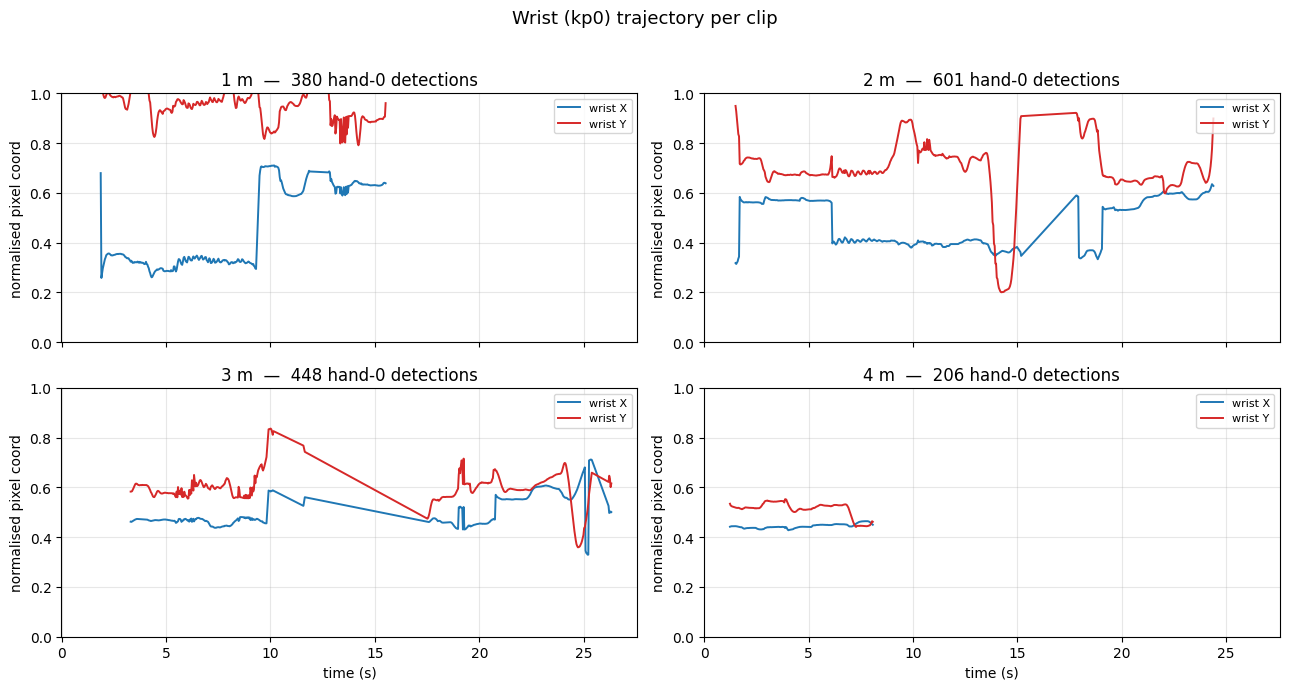

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

for ax, c in zip(axes.flat, CLIPS):
    kp = pd.read_csv(c['prefix'].with_name(c['prefix'].name + '_keypoints.csv'))
    # Use hand 0 only for clarity.
    h0 = kp[kp['hand_index'] == 0]
    if len(h0):
        ax.plot(h0['time_seconds'], h0['kp0_x'], color='#1f77b4', lw=1.4, label='wrist X')
        ax.plot(h0['time_seconds'], h0['kp0_y'], color='#d62828', lw=1.4, label='wrist Y')
    ax.set_title(f"{c['dist_m']} m  —  {len(h0)} hand-0 detections")
    ax.set_ylim(0, 1)
    ax.set_ylabel('normalised pixel coord')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel('time (s)')

plt.suptitle('Wrist (kp0) trajectory per clip', fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


## 4. Sample overlay frames

One frame from the middle of each overlay video so you can eyeball the actual skeleton quality at each range.

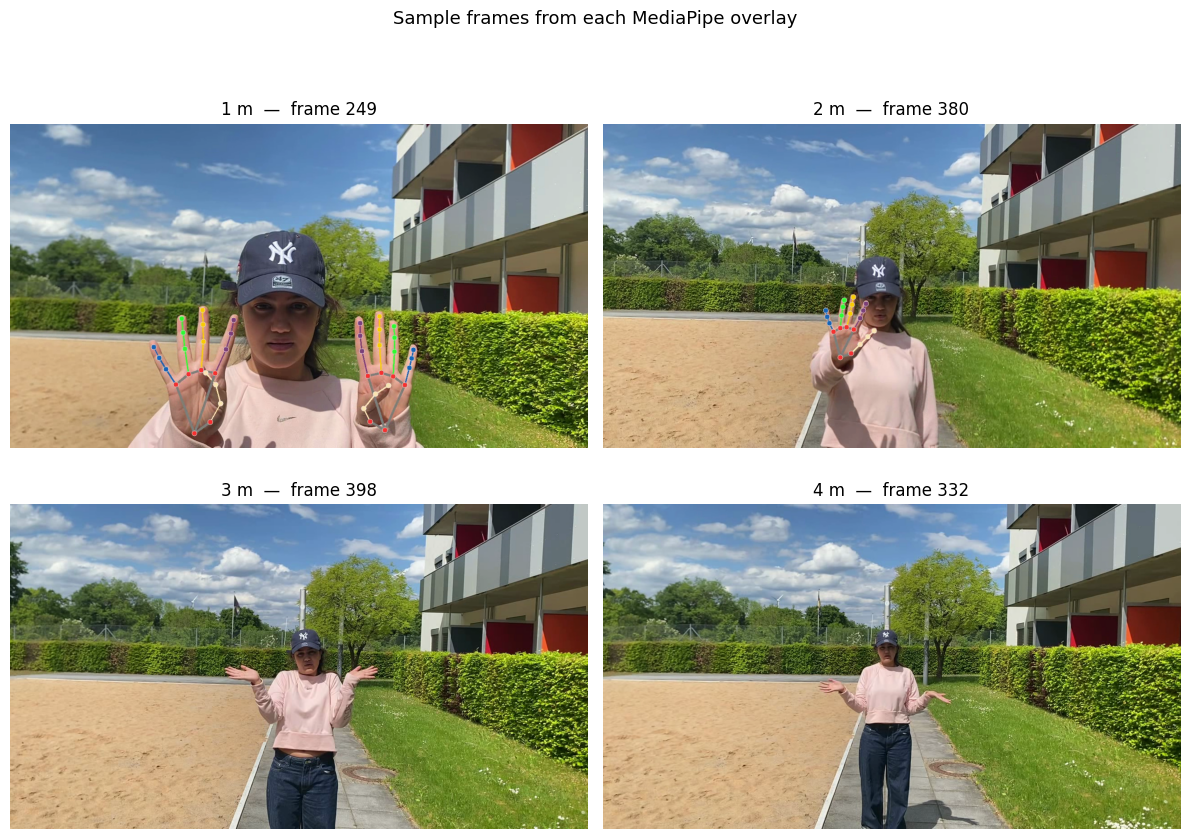

In [6]:
import cv2

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, c in zip(axes.flat, CLIPS):
    overlay = c['prefix'].with_name(c['prefix'].name + '_overlay.mp4')
    cap = cv2.VideoCapture(str(overlay))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, n // 2)
    ok, frame = cap.read()
    cap.release()
    if ok:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{c['dist_m']} m  —  frame {n//2}")
    ax.axis('off')
plt.suptitle('Sample frames from each MediaPipe overlay', fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


## 5. Per-clip overlay videos (interactive)

These are the full overlay videos. Use them for visual debugging — for example to find frames where MediaPipe outputs a noisy skeleton or swaps left/right hand.

In [7]:
from IPython.display import Video, display
for c in CLIPS:
    overlay = c['prefix'].with_name(c['prefix'].name + '_overlay.mp4')
    if overlay.exists():
        print(f"{c['dist_m']} m  →  {overlay}")
        display(Video(str(overlay), embed=False))


1 m  →  /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/gesture/1m_overlay.mp4


2 m  →  /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/gesture/2m_overlay.mp4


3 m  →  /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/gesture/3m_overlay.mp4


4 m  →  /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/gesture/4m_overlay.mp4


## 6. What does MediaPipe actually give us per detected hand?

This is the bridge between Phase 1 (detect) and Phase 2 (classify). The cells below open one CSV (`1m_keypoints.csv`) and walk through the schema in detail.

**Per detected hand, per frame, MediaPipe Hands emits:**

| Field | Meaning |
| --- | --- |
| `frame`, `time_seconds` | Frame index and timestamp in the source video. |
| `hand_index` | 0 for the first hand returned in this frame, 1 for the second (up to `max_hands` was set to 2). The mapping is *not* stable across frames — we have to re-associate it using either `handedness` or a nearest-neighbour assignment if we need consistent hand IDs. |
| `handedness` | `"Left"` / `"Right"` as inferred from the image (mirror-flipped vs. real world). |
| `score` | Per-frame detection confidence ∈ [0, 1]. We typically threshold below ~0.5 for reliable downstream use. |
| `kp{0..20}_x`, `kp{0..20}_y` | 21 landmark coordinates in **normalised image space** (`(0, 0)` top-left, `(1, 1)` bottom-right). Multiplying by frame width / height gives pixels. |
| `kp{0..20}_z` | Depth *relative to the wrist*. Same units as `x`. Positive z is **behind** the wrist (away from camera). MediaPipe says explicitly this is "the smaller the value, the closer the landmark is to the camera." Useful as a relative cue, **not** a metric depth. |

**The 21 keypoints** (MediaPipe canonical order):

| index | name | index | name |
| ---: | --- | ---: | --- |
| 0 | wrist | 11 | middle finger PIP |
| 1 | thumb CMC | 12 | middle finger DIP |
| 2 | thumb MCP | 13 | middle finger tip |
| 3 | thumb IP | 14 | ring finger MCP |
| 4 | thumb tip | 15 | ring finger PIP |
| 5 | index finger MCP | 16 | ring finger DIP |
| 6 | index finger PIP | 17 | ring finger tip |
| 7 | index finger DIP | 18 | pinky MCP |
| 8 | index finger tip | 19 | pinky PIP |
| 9 | middle finger MCP | 20 | pinky DIP / tip |
| 10 | middle finger PIP | | |

(MCP = base joint, PIP/DIP = middle joints, tip = fingertip.)


In [8]:
import pandas as pd, numpy as np

kp = pd.read_csv(CLIPS[0]['prefix'].with_name(CLIPS[0]['prefix'].name + '_keypoints.csv'))
print('Schema (first 10 columns):')
print(kp.columns.tolist()[:10], '...')
print(f"\nTotal hand instances in 1 m clip: {len(kp)}")
print(f"\nFirst two rows, only metadata + a couple of landmarks:")
display(kp[['frame', 'time_seconds', 'hand_index', 'handedness', 'score',
            'kp0_x', 'kp0_y', 'kp0_z',
            'kp8_x', 'kp8_y', 'kp8_z',
            'kp12_x', 'kp12_y', 'kp12_z']].head(2))


Schema (first 10 columns):
['frame', 'time_seconds', 'hand_index', 'handedness', 'score', 'kp0_x', 'kp0_y', 'kp0_z', 'kp1_x', 'kp1_y'] ...

Total hand instances in 1 m clip: 643

First two rows, only metadata + a couple of landmarks:


,frame,time_seconds,hand_index,handedness,score,kp0_x,kp0_y,kp0_z,kp8_x,kp8_y,kp8_z,kp12_x,kp12_y,kp12_z
0,56,1.868353,0,Right,0.938909,0.679317,1.048577,2.939501e-07,0.644699,0.775585,-0.073314,0.687262,0.744126,-0.071209
1,57,1.901717,0,Left,0.973140,0.257908,1.045722,2.488844e-07,0.287555,0.770190,-0.084484,0.243130,0.741945,-0.086989


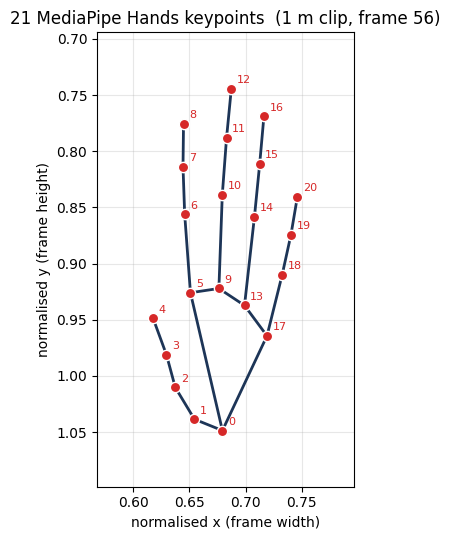

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Static MediaPipe hand connections (pairs of keypoint indices)
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),                # thumb
    (0, 5), (5, 6), (6, 7), (7, 8),                # index
    (5, 9), (9, 10), (10, 11), (11, 12),           # middle
    (9, 13), (13, 14), (14, 15), (15, 16),         # ring
    (13, 17), (17, 18), (18, 19), (19, 20),        # pinky
    (0, 17),                                       # palm bottom
]

# Take the first detected frame from the 1 m clip
kp = pd.read_csv(CLIPS[0]['prefix'].with_name(CLIPS[0]['prefix'].name + '_keypoints.csv'))
row = kp[kp['hand_index'] == 0].iloc[0]
xs = np.array([row[f'kp{i}_x'] for i in range(21)])
ys = np.array([row[f'kp{i}_y'] for i in range(21)])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
# Draw bones
for a, b in HAND_CONNECTIONS:
    ax.plot([xs[a], xs[b]], [ys[a], ys[b]], '-', color='#1d3557', lw=2.0)
# Draw joints with index labels
ax.scatter(xs, ys, c='#d62828', s=55, zorder=5, edgecolors='white', linewidths=1.0)
for i in range(21):
    ax.text(xs[i] + 0.005, ys[i] - 0.005, str(i), fontsize=8, color='#d62828')

ax.set_title(f"21 MediaPipe Hands keypoints  (1 m clip, frame {int(row['frame'])})")
ax.set_xlim(min(xs) - 0.05, max(xs) + 0.05)
ax.set_ylim(max(ys) + 0.05, min(ys) - 0.05)   # flip Y so it reads top-down like an image
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_xlabel('normalised x (frame width)')
ax.set_ylabel('normalised y (frame height)')
plt.tight_layout()
plt.show()


## 7. How these outputs feed the gesture classifier (Phase 2)

The 21 × 3 landmark stream is exactly the input shape a small temporal model wants. Concretely:

**A. Static gesture classifier (single-frame).**

* Input: 21 × 3 = 63-dim vector per detected hand, **normalised** to a wrist-centred frame:
  * subtract `kp0` (wrist) from every keypoint → translation invariant
  * divide by the wrist-to-middle-MCP distance (`kp0` ↔ `kp9`) → scale invariant
  * optionally mirror so left/right hands map to the same canonical form
* Output: gesture label (e.g. `open_palm`, `fist`, `point`, `thumbs_up`, ...).
* Model: a 3-layer MLP / small Transformer encoder over a single 63-dim vector. Tiny (~50k params), runs in < 1 ms per frame.
* Sanity expectation: at 1–2 m we already have enough resolution; this baseline should reach 90 %+ on a controlled gesture set.

**B. Dynamic gesture classifier (short window).**

* Input: a 21 × 3 × T tensor (T = 30 – 60 frames, i.e. 1 – 2 s at 30 fps). Same wrist-centred normalisation per frame, optionally per-frame velocities (`Δkp_t = kp_t − kp_{t-1}`).
* Output: label per window (e.g. `wave`, `swipe_left`, `come_here`, `stop`).
* Model: a 1-D temporal CNN or small Transformer over T frames. Still small (< 200k params).
* Strong against classes that only differ in motion (open palm vs. wave both have the same per-frame pose).

**C. Hand-crop CNN (distance-robust fallback).**

Because the detection rate drops sharply past 2 m, the keypoint-only classifier inherits that distance limit. To keep the classifier working at 3–4 m we add a **crop-then-classify** branch:

1. MediaPipe returns a per-frame hand bounding box (we can derive it from the 21 keypoints' bbox + a 1.4× scale margin).
2. Crop that box, **resize to 224 × 224** → always a constant-resolution input.
3. Run a small image classifier (MobileNetV3 / EfficientNet-Lite) on the crop, with the same gesture label set.

This branch ignores the keypoints entirely and uses the appearance, so it can recover information that MediaPipe loses at distance (it can fail to *track* keypoints but still pass through a usable crop).

**D. Late fusion.** Predict with (A or B) and (C), take the argmax of the averaged softmax. Empirically this gives the keypoint head's accuracy at near range and the crop head's robustness at far range.

**Where the existing CSVs already help.** The cells above show that `data/gesture/{1,2,3,4}m_keypoints.csv` already contain everything (A) and (B) need; we just have to label gesture intervals. The next notebook (`05_gesture_classifier_baseline.ipynb`, TODO) will:

1. Add a `data/gesture/labels.csv` (`clip`, `t_start`, `t_end`, `gesture`) — short manual annotation pass.
2. Cut and split into train / val / test by **person + distance** to avoid leakage.
3. Train baseline A on the keypoint vectors; report distance-stratified accuracy.
4. Bolt on baseline C (crop classifier) and report fusion accuracy.


In [10]:
def normalise_hand(row) -> np.ndarray:
    """Return a 21 x 3 array centred on the wrist and scaled by wrist-to-MCP9."""
    pts = np.array([[row[f'kp{i}_x'], row[f'kp{i}_y'], row[f'kp{i}_z']] for i in range(21)])
    pts = pts - pts[0]                       # centre on wrist
    scale = np.linalg.norm(pts[9])           # |wrist -> middle MCP|
    if scale < 1e-6:
        return pts
    return pts / scale

kp = pd.read_csv(CLIPS[0]['prefix'].with_name(CLIPS[0]['prefix'].name + '_keypoints.csv'))
row = kp[kp['hand_index'] == 0].iloc[0]
norm = normalise_hand(row)

print(f"Normalised hand vector shape: {norm.shape}")
print(f"Wrist (kp0) after normalisation:        {norm[0]}")
print(f"Middle finger MCP (kp9) after norm:     {norm[9]} (unit length by construction)")
print(f"Index tip (kp8) after normalisation:    {norm[8]}")
print(f"Flattened input for the classifier (length {norm.size}):")
print(np.round(norm.flatten(), 3))


Normalised hand vector shape: (21, 3)
Wrist (kp0) after normalisation:        [0. 0. 0.]
Middle finger MCP (kp9) after norm:     [-0.02375349 -0.95673162 -0.29000066] (unit length by construction)
Index tip (kp8) after normalisation:    [-0.26191115 -2.06538699 -0.55467495]
Flattened input for the classifier (length 63):
[ 0.000e+00  0.000e+00  0.000e+00 -1.880e-01 -7.600e-02 -1.460e-01
 -3.170e-01 -2.900e-01 -2.610e-01 -3.770e-01 -5.100e-01 -3.590e-01
 -4.660e-01 -7.550e-01 -4.630e-01 -2.150e-01 -9.280e-01 -2.750e-01
 -2.540e-01 -1.455e+00 -4.070e-01 -2.650e-01 -1.777e+00 -4.950e-01
 -2.620e-01 -2.065e+00 -5.550e-01 -2.400e-02 -9.570e-01 -2.900e-01
 -1.000e-03 -1.588e+00 -4.010e-01  2.800e-02 -1.973e+00 -4.800e-01
  6.000e-02 -2.303e+00 -5.390e-01  1.490e-01 -8.420e-01 -3.130e-01
  2.160e-01 -1.441e+00 -4.240e-01  2.510e-01 -1.795e+00 -4.920e-01
  2.790e-01 -2.115e+00 -5.390e-01  3.000e-01 -6.380e-01 -3.440e-01
  4.030e-01 -1.050e+00 -4.500e-01  4.610e-01 -1.317e+00 -4.900e-01
  5.050

## 8. What else could we use? — alternative hand-keypoint detectors

MediaPipe Hands is fast and easy to bring up, but it is **single-image, two-stage (palm detector → landmark net)** trained mostly on close-range hands. The numbers in Section 2 (detection rate halves between 2 m and 4 m) sit in the sweet spot of MediaPipe; if we want a usable gesture classifier at 3–5 m we should at least benchmark stronger / more flexible alternatives.

The shortlist below is ranked by how easy it is to drop into the current pipeline (CSV input → temporal model output stays unchanged).

| Detector | Keypoints / output | Strengths | Weaknesses | Why we'd try it |
|---|---|---|---|---|
| **MediaPipe Tasks `HandLandmarker`** | Same 21 kp, but new TFLite-based API | Newer model, GPU delegate (Metal on M-series), tunable `num_hands`, segmentation-aware palm crop. | Same fundamental architecture so distance limits will be similar. | Quickest A/B test — usually a few % better detection rate vs. the legacy `mp.solutions.hands`. |
| **MMPose `RTMPose-Hand`** | 21 hand kp (compatible) | Larger model, native FP16 / TensorRT, much higher recall at small hand size. SOTA on hand keypoint benchmarks (FreiHAND, RHD). | Heavier (~30 ms/frame on CPU), needs OpenMMLab install. | Best chance of recovering detections at 3–4 m. |
| **MMPose `RTMPose-WholeBody`** | 133 kp including 21 per hand | Detects hands **through body context** — if the person is visible, the hand keypoints "come along for free". | Even heavier (~50 ms/frame CPU). | Lets us bypass the "is the hand visible?" question — at distance the body is far easier to detect than the hand. |
| **YOLOv8x-Pose (custom hand-trained head)** | Bounding box + 21 hand kp | Single-pass, fast on GPU, can be retrained on a custom hand-pose dataset. | Off-the-shelf YOLOv8-Pose is body-only; needs a hand-keypoint dataset for fine-tuning. | If we end up needing real-time on-device inference and the platform supports YOLO. |
| **Frankmocap / HaMeR (3D hand)** | MANO 3D mesh + 778 vertices | Full 3D hand shape and pose, robust to viewpoint. | Heavy (transformer-based), slow on CPU, more annotation work. | Useful if we need *3D* gesture invariance (camera-angle-robust). |
| **Apple `VNDetectHumanHandPoseRequest`** | 21 kp very close to MediaPipe schema | Runs on-device on iPhone with Neural Engine, no extra install. | Only iOS / macOS. | Useful path if we move the demo onto the phone we already use for VIO. |
| **Two-stage: YOLOv8-person + MediaPipe on crop** | 21 kp (same schema) | Trivially fixes the distance problem — person detection works far past 5 m, and the hand crop is then a "near-range" problem MediaPipe handles well. | Adds 1 extra detector per frame; needs hand-region heuristic on the body crop. | **Most pragmatic next step** — reuses everything we already built (`vio/run_yolo_foot.py`) and the MediaPipe pipeline unchanged. |

### Concrete experiment plan

1. **Re-run the same 4 clips with `mediapipe.tasks.vision.HandLandmarker`** and compare detection rate & score to the table in Section 2. Same CSV schema, drop-in replacement.
2. **Add a "person crop" stage**: detect the person with YOLOv8s (already cached in `vio/run_yolo_foot.py`), expand to the upper body, then run MediaPipe Hands on the crop. Report detection rate at 3 m and 4 m — expecting a large jump.
3. **If still insufficient at 4 m**, bring in RTMPose-Hand (MMPose) for the 3–4 m clips and run the same CSV/classifier downstream — no other code change needed because we kept the 21 × 3 schema.

These three experiments are roughly: 1 day, 1 day, 2–3 days of engineering, respectively, and each one strictly improves the lower-end (far-distance) of the classifier's working range.


## 9. Findings — implications for the gesture classifier

* **MediaPipe Hands works well at ≤ 2 m** (detection rate ~ 76 – 79 %, mean score > 0.96, hand fills 13 – 35 % of the frame). At this range every 21-keypoint sample is reliable enough to feed a downstream classifier directly.
* **Performance halves between 2 m and 4 m**. At 3 m we still get 56 % detection, but the hand is only ~ 8 % of the frame, so finger-level geometry is already noisy. At 4 m we lose two thirds of frames and the hand is ~ 5 % of the frame.
* **Apparent hand size follows the expected `~ 1/d` law** (see the grey reference curve), so this is a geometry limit, not a detector failure mode. The fix is more pixels on the hand: zoom, crop-around-detected-bbox before classification, or a wider-angle lens at the cost of FOV reach.

### Concrete plan for the gesture classifier (next notebooks)

1. **Define a small set of target gestures** (e.g. open palm, fist, point, thumbs-up). Re-record using the same protocol so distance is controlled.
2. **Crop-then-classify**: at inference, use MediaPipe's per-frame hand bbox to crop a 224 × 224 patch and run a small CNN — keeps the classifier resolution constant regardless of distance.
3. **Temporal model on the 21-keypoint stream** as a parallel baseline (LSTM / small Transformer over a 1 – 2 s window). Compare against the crop-and-classify route.
4. **Distance-stratified evaluation**: report classifier accuracy separately for 1 m, 2 m, 3 m (4 m clips will likely have to be discarded or used only as held-out hard examples).

### Reproducibility commands

```bash
# Per-clip MediaPipe run
python -m gesture.mediapipe_overlay \
  --video  ~/Desktop/uav_perception/media_hands/1meters.MOV \
  --output-prefix data/gesture/1m \
  --max-hands 2 --detection-confidence 0.5 --tracking-confidence 0.5

# ... same for 2/3/4 meters .MOV
```
